<a href="https://colab.research.google.com/github/jaewoo-cho/jaewoo/blob/master/31_scikit_learn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 사이킷런(scikit-learn)

![](https://scipy-lectures.org/_images/scikit-learn-logo.png)




In [ ]:
# 기본 import

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# scikit-learn 특징

* 다양한 머신러닝 알고리즘을 구현한 파이썬 라이브러리
* 심플하고 일관성 있는 API, 유용한 온라인 문서, 풍부한 예제
* 머신러닝을 위한 쉽고 효율적인 개발 라이브러리 제공
* 다양한 머신러닝 관련 알고리즘과 개발을 위한 프레임워크와 API 제공
* 많은 사람들이 사용하며 다양한 환경에서 검증된 라이브러리


# scikit-learn 주요모듈

| 모듈 | 설명 |
|------|------|
| `sklearn.datasets` | 내장된 예제 데이터 세트 |
| `sklearn.preprocessing` | 다양한 데이터 전처리 기능 제공 (변환, 정규화, 스케일링 등) |
| `sklearn.feature_selection` | 특징(feature)를 선택할 수 있는 기능 제공 |
| `sklearn.feature_extraction` | 특징(feature) 추출에 사용 |
| `sklearn.decomposition` | 차원 축소 관련 알고리즘 지원 (PCA, NMF, Truncated SVD 등)
| `sklearn.model_selection` | 교차 검증을 위해 데이터를 학습/테스트용으로 분리, 최적 파라미터를 추출하는 API 제공 (GridSearch 등)
| `sklearn.metrics` | 분류, 회귀, 클러스터링, Pairwise에 대한 다양한 성능 측정 방법 제공 (Accuracy, Precision, Recall, ROC-AUC, RMSE 등) |
| `sklearn.pipeline` | 특징 처리 등의 변환과 ML 알고리즘 학습, 예측 등을 묶어서 실행할 수 있는 유틸리티 제공 |
| `sklearn.linear_model` | 선형 회귀, 릿지(Ridge), 라쏘(Lasso), 로지스틱 회귀 등 회귀 관련 알고리즘과 SGD(Stochastic Gradient Descent) 알고리즘 제공 |
| `sklearn.svm` | 서포트 벡터 머신 알고리즘 제공 |
| `sklearn.neighbors` | 최근접 이웃 알고리즘 제공 (k-NN 등)
| `sklearn.naive_bayes` | 나이브 베이즈 알고리즘 제공 (가우시안 NB, 다항 분포 NB 등) |
| `sklearn.tree` | 의사 결정 트리 알고리즘 제공 |
| `sklearn.ensemble` | 앙상블 알고리즘 제공 (Random Forest, AdaBoost, GradientBoost 등) |
| `sklearn.cluster` | 비지도 클러스터링 알고리즘 제공 (k-Means, 계층형 클러스터링, DBSCAN 등)


# `estimator` API

* 일관성: 모든 객체는 일관된 문서를 갖춘 제한된 메서드 집합에서 비롯된 공통 인터페이스 공유
* 검사(inspection): 모든 지정된 파라미터 값은 공개 속성으로 노출
* 제한된 객체 계층 구조
  + 알고리즘만 파이썬 클래스에 의해 표현
  + 데이터 세트는 표준 포맷(NumPy 배열, Pandas DataFrame, Scipy 희소 행렬)으로 표현
  + 매개변수명은 표준 파이썬 문자열 사용
* 구성: 많은 머신러닝 작업은 기본 알고리즘의 시퀀스로 나타낼 수 있으며, Scikit-Learn은 가능한 곳이라면 어디서든 이 방식을 사용
* 합리적인 기본값: 모델이 사용자 지정 파라미터를 필요로 할 때 라이브러리가 적절한 기본값을 정의


## API 사용 방법

1. Scikit-Learn으로부터 적절한 `estimator` 클래스를 임포트해서 모델의 클래스 선택
2. 클래스를 원하는 값으로 인스턴스화해서 모델의 하이퍼파라미터 선택
3. 데이터를 특징(feature) 배열과 대상(target) 벡터로 배치
  - 보통 X, y 로 표현
4. 모델 인스턴스의 `fit()` 메서드를 호출해 모델을 데이터에 적합
5. 모델을 새 데이터에 대해서 적용
  + 지도 학습: 대체로 `predict()` 메서드를 사용해 알려지지 않은 데이터에 대한 레이블 예측
  + 비지도 학습: 대체로 `transform()`이나 `predict()` 메서드를 사용해 데이터의 속성을 변환하거나 추론

## cheat-sheet (어떤 알고리즘을 선택?)

https://scikit-learn.org/stable/machine_learning_map.html


# 예제 데이터 세트

## 분류(classification) 또는 회귀용(regression) 데이터 세트

| API | 설명 |
|-----|------|
| `datasets.load_boston()` | 미국 보스턴의 집에 대한 특징과 가격 데이터 (회귀용) |
| `datasets.load_breast_cancer()` | 위스콘신 유방암 특징들과 악성/음성 레이블 데이터 (분류용) |
| `datasets.load_diabetes()` | 당뇨 데이터 (회귀용) |
| `datasets.load_digits()` | 0에서 9까지 숫자 이미지 픽셀 데이터 (분류용) |
| `datasets.load_iris()` | 붓꽃에 대한 특징을 가진 데이터 (분류용) |


## 온라인 데이터 세트

* 데이터 크기가 커서 온라인에서 데이터를 다운로드 한 후에 불러오는 예제 데이터 세트

| API | 설명 |
|-----|------|
| `fetch_california_housing()` | 캘리포니아 주택 가격 데이터 |
| `fetch_covtype()` | 회귀 분석용 토지 조사 데이터 |
| `fetch_20newsgroups()` | 뉴스 그룹 텍스트 데이터 |
| `fetch_olivetti_faces()` | 얼굴 이미지 데이터 |
| `fetch_lfw_people()` | 얼굴 이미지 데이터 |
| `fetch_lfw_paris()` | 얼굴 이미지 데이터 |
| `fetch_rcv1()` | 로이터 뉴스 말뭉치 데이터 |
| `fetch_mldata()` | ML 웹사이트에서 다운로드 |


## 분류와 클러스터링을 위한 표본 데이터 생성

| API | 설명 |
|-----|------|
| `datasets.make_classifications()` | 분류를 위한 데이터 세트 생성. 높은 상관도, 불필요한 속성 등의 노이즈를 고려한 데이터를 무작위로 생성 |
| `datasets.make_blobs()` | 클러스터링을 위한 데이터 세트 생성. 군집 지정 개수에 따라 여러 가지 클러스터링을 위한 데이터 셋트를 무작위로 생성 |


## 예제 데이터 세트 구조

* 일반적으로 딕셔너리 형태로 구성
* data: 특징 데이터 세트
* target: 분류용은 레이블 값, 회귀용은 숫자 결과값 데이터
* target_names: 개별 레이블의 이름 (분류용)
* feature_names: 특징 이름
* DESCR: 데이터 세트에 대한 설명과 각 특징 설명


In [ ]:
from sklearn.datasets import load_diabetes # 당뇨병 데이터

In [ ]:
diabetes = load_diabetes()

print(diabetes.keys())

dict_keys(['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module'])


In [ ]:
print(diabetes.data)

[[ 0.03807591  0.05068012  0.06169621 ... -0.00259226  0.01990749
  -0.01764613]
 [-0.00188202 -0.04464164 -0.05147406 ... -0.03949338 -0.06833155
  -0.09220405]
 [ 0.08529891  0.05068012  0.04445121 ... -0.00259226  0.00286131
  -0.02593034]
 ...
 [ 0.04170844  0.05068012 -0.01590626 ... -0.01107952 -0.04688253
   0.01549073]
 [-0.04547248 -0.04464164  0.03906215 ...  0.02655962  0.04452873
  -0.02593034]
 [-0.04547248 -0.04464164 -0.0730303  ... -0.03949338 -0.00422151
   0.00306441]]


In [ ]:
diabetes.data.shape

# 442샘플 x 10개의 feature

(442, 10)

In [ ]:
# 첫번째 샘플
diabetes.data[0] # 이미 scaling(전처리)된 값

array([ 0.03807591,  0.05068012,  0.06169621,  0.02187239, -0.0442235 ,
       -0.03482076, -0.04340085, -0.00259226,  0.01990749, -0.01764613])

In [ ]:
diabetes.feature_names

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

In [ ]:
print(diabetes.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [ ]:
diabetes.target

array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
        69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
        68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
        87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
       259.,  53., 190., 142.,  75., 142., 155., 225.,  59., 104., 182.,
       128.,  52.,  37., 170., 170.,  61., 144.,  52., 128.,  71., 163.,
       150.,  97., 160., 178.,  48., 270., 202., 111.,  85.,  42., 170.,
       200., 252., 113., 143.,  51.,  52., 210.,  65., 141.,  55., 134.,
        42., 111.,  98., 164.,  48.,  96.,  90., 162., 150., 279.,  92.,
        83., 128., 102., 302., 198.,  95.,  53., 134., 144., 232.,  81.,
       104.,  59., 246., 297., 258., 229., 275., 281., 179., 200., 200.,
       173., 180.,  84., 121., 161.,  99., 109., 115., 268., 274., 158.,
       107.,  83., 103., 272.,  85., 280., 336., 281., 118., 317., 235.,
        60., 174., 259., 178., 128.,  96., 126., 28

In [ ]:
diabetes.target.shape

(442,)

In [ ]:
diabetes.data_filename

'diabetes_data_raw.csv.gz'

# `model_selection` 모듈

* 학습용 데이터와 테스트 데이터로 분리
* 교차 검증 분할 및 평가
* Estimator의 하이퍼 파라미터 튜닝을 위한 다양한 함수와 클래스 제공


## `train_test_split()`: 학습/테스트 데이터 세트 분리


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [ ]:
# train:test = 7:3
X_train, X_test, y_train, y_test = \
train_test_split(diabetes.data, diabetes.target, test_size=0.3, random_state=42)

In [ ]:
X_train.shape, y_train.shape

((309, 10), (309,))

In [ ]:
X_test.shape, y_test.shape

((133, 10), (133,))

# `preprocessing` 데이터 전처리 모듈

In [ ]:
# scikit-learn 의 preprocessing 모듈
# 데이터 전처리 는 많은 작업들을 하게 되는데,
# 대표적인게 scaling 입니다.
# 데이터의 feature scaling 이라고도 합니다.

# scaling 방법은 크게 두가지가 있습니다.
#  1. 표준화 (standardization)
#  2. 정규화 (normalization)

# 정규화와 표준화는 모두 머신러닝 알고리즘을 훈련시키는데 있어서
# 사용되는 특성(feature)들이 '모두 비슷한 영향력'을 행사하도록
# 값을 변환해주는 전처리 기술입니다


![](https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdn%2FxaTIu%2FbtqFzbvLruS%2FKwRY1VUfZIhSKNd6nV97K0%2Fimg.jpg)


* 데이터의 특징 스케일링(feature scaling)을 위한 방법으로 표준화(Standardization)와 정규화(Normalization) 사용

+ 표준화 방법

\begin{equation}
x_i^{'} = \frac{x_i-mean(x)}{stdev(x)}
\end{equation}

+ 정규화 방법

\begin{equation}
x_i^{'} = \frac{x_i-min(x)}{max(x)-min(x)}
\end{equation}

+ scikit-learn에서는 개별 벡터 크기를 맞추는 형태로 정규화


## `StandardScaler`: 표준화 클래스


In [ ]:
from sklearn.datasets import load_iris

In [ ]:
iris = load_iris()

In [ ]:
iris_df = pd.DataFrame(data = iris.data, columns = iris.feature_names)
iris_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [ ]:
iris_df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()

In [ ]:
# 스케일링을 위해 몇가지 과정을 거쳐야 한다
# step 1 : 기본적으로 fit() 을 하여 scaling에 필요한 정보들을 가져옵니다.
# step 2 : 가져온 정보에 따라서 scaling 을 위한 transform() 메소드를 호출하여
#          scaling 된 변환을 거칩니다.

# 위 step1, step2 를 '동시에' 에 수행하는 fit_transform()

In [ ]:
# 방법1 : fit() + transform()
scaler.fit(iris_df)
iris_scaled = scaler.transform(iris_df)

In [ ]:
# 방법2
iris_scaled = scaler.fit_transform(iris_df)

In [ ]:
type(iris_scaled)

numpy.ndarray

In [ ]:
iris_df_scaled = pd.DataFrame(data = iris_scaled, columns=iris.feature_names)
iris_df_scaled.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,1.500000e+02,1.500000e+02,1.500000e+02,1.500000e+02
mean,-1.468455e-15,-1.823726e-15,-1.610564e-15,-9.473903e-16
std,1.003350e+00,1.003350e+00,1.003350e+00,1.003350e+00
min,-1.870024e+00,-2.433947e+00,-1.567576e+00,-1.447076e+00
25%,-9.006812e-01,-5.923730e-01,-1.226552e+00,-1.183812e+00
50%,-5.250608e-02,-1.319795e-01,3.364776e-01,1.325097e-01
75%,6.745011e-01,5.586108e-01,7.627583e-01,7.906707e-01
max,2.492019e+00,3.090775e+00,1.785832e+00,1.712096e+00


## `MinMaxScaler`: 정규화 클래스


In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
scaler = MinMaxScaler()

In [ ]:
fit_scaler = scaler.fit(iris_df) # 리턴값은 scaler 객체. 학습된 모델에 새로운 관측치를 넣을때 적용해야 함
iris_scaled = scaler.transform(iris_df) # scale 된 결과 리턴(array)

In [ ]:
fit_scaler == scaler

True

In [ ]:
iris_df_scaled = pd.DataFrame(data = iris_scaled, columns=iris.feature_names)
iris_df_scaled.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,0.428704,0.440556,0.467458,0.458056
std,0.230018,0.181611,0.299203,0.317599
min,0.000000,0.000000,0.000000,0.000000
25%,0.222222,0.333333,0.101695,0.083333
50%,0.416667,0.416667,0.567797,0.500000
75%,0.583333,0.541667,0.694915,0.708333
max,1.000000,1.000000,1.000000,1.000000


# 성능 평가 지표
matrics 모듈

## 정확도(Accuracy)

* 정확도는 전체 예측 데이터 건수 중 예측 결과가 동일한 데이터 건수로 계산
* scikit-learn에서는 `accuracy_score` 함수를 제공




In [ ]:
from sklearn.datasets import make_classification # 랜덤으로 분류형 데이터셋 생성

In [ ]:
X, y = make_classification(
    n_samples=1000,   # 생성할 데이터 개수
    n_features=2,    # feature 의 개수
    n_informative=2,  # 의미있는 feature 의 개수
    n_redundant= 0,   # 일종의 노이즈.  (0, <- 순수하게 생성)
    n_clusters_per_class=1,   # 클래스당 하나의 클러스만 나올수 있게 하기.
    random_state=42,      # 랜덤시드
    n_classes=2,       # class 개수 (디폴트 2)
)

In [ ]:
X

array([[ 0.60103418,  1.5353525 ],
       [ 0.75594526, -1.1723519 ],
       [ 1.35447877, -0.94852841],
       ...,
       [ 2.84431506,  0.21129354],
       [-0.02587554,  1.6192578 ],
       [ 3.64147835,  0.75692519]])

In [ ]:
y

array([1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1,
       0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0,
       1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1,

In [ ]:
X_train, X_test, y_train, y_test = \
train_test_split(X,y, test_size=0.3, random_state=42)

In [ ]:
X_train.shape, X_test.shape

((700, 2), (300, 2))

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
model = LogisticRegression()

In [ ]:
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
print('훈련데이터 점수:', model.score(X_train, y_train))
print('테스트데이터 점수:', model.score(X_test, y_test))

훈련데이터 점수: 0.9185714285714286
테스트데이터 점수: 0.8833333333333333


In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
predict = model.predict(X_test)

print('정확도:', accuracy_score(y_test, predict)) #accuracy_score(정답, 예측값)

정확도: 0.8833333333333333


In [ ]:
# 데이터의 분포가 균일하지 않은 경우...
# 균일하지 않은 상태에도 정확도는 높게 나올수가 있는 겁니다.   (정확도의 단점?)

# '정확도(accuracy)' 만 가지고 성능이 좋다 나쁘다 를 판단하긴 어렵다.

# 그러면 정확도 말고 어떤것이 있나?
# 다양한 평가 지표를 살펴 보도록 하겠습니다

## 오차 행렬(Confusion Matrix)

* True Negative: 예측값을 Negative 값 0으로 예측했고, 실제 값도 Negative 값 0
* False Positive: 예측값을 Positive 값 1로 예측했는데, 실제 값은 Negative 값 0
* False Negative: 예측값을 Negative 값 0으로 예측했는데, 실제 값은 Positive 값 1
* True Positive: 예측값을 Positive 값 1로 예측했고, 실제 값도 Positive 값 1

![](https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Ft1.daumcdn.net%2Fcfile%2Ftistory%2F99DC064C5BE056CE10)


In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
confmat = confusion_matrix(y_true = y_test, y_pred=predict)
confmat # 2차원 배열

array([[137,  10],
       [ 25, 128]])

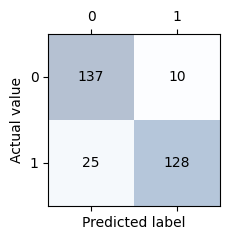

In [ ]:
# 시각화
fig, ax = plt.subplots(figsize=(2.5, 2.5))
ax.matshow(confmat, cmap=plt.cm.Blues, alpha=0.3)

for i in range(confmat.shape[0]):
  for j in range(confmat.shape[1]):
    ax.text(x=j, y=i, s=confmat[i,j],
            va='center',
            ha='center',
            )

plt.xlabel('Predicted label')
plt.ylabel('Actual value')
plt.tight_layout()
plt.show()

## 정밀도(Precision)와 재현율(Recall)

* 정밀도(Precision) = TP / (FP + TP)
* 재현율(Recall) = TP / (FN + TP)

* 정확도(accuracy) = (TN + TP) / (TN + FP + FN + TP)
* 오류율 = (FN + FP) / (TN + FP + FN + TP)


In [ ]:
from sklearn.metrics import precision_score, recall_score

In [ ]:
precision = precision_score(y_test, predict)
recall = recall_score(y_test, predict)

print('predicion:', precision)
print('recall:', recall)

predicion: 0.927536231884058
recall: 0.8366013071895425


In [ ]:
# 업무 특성에 따라
# 재현율이 상대적으로 더 중요한 지표인 경우는 실제 Positive 양성인 데이터 예측을 Negative 음성으로 잘못 판단하게 되면 업무상 큰 영향이 발생하는 경우
# 정밀도가 상대적으로 더 중요한 지표인 경우는 실제 Negative 음성인 데이터 예측을 Positive 양성으로 잘못 판단하게 되면 업무상 큰 영향이 발생하는 경우

# 재현율이 중요한 경우 -> 암 판단 모델이나 금융 사기 적발 모델과 같이 실제 Positive 양성 데이터를 Negative로 잘못 판단하게 되면 업무상 큰 영향이 발생하는 경우이다.
#                         암 인데(Positive)  암이 아니라고 (Negative) 잘못 판단하면 위험.

# 정밀도가 중요한 경우 -> 스팸메일 여부를 판단하는 모델과 같은 경우는 정밀도가 더 중요한 지표
#                         스팸이아닌데 (Negative)  스팸이라고(Positive) 잘못 판단하면 곤란



In [ ]:
# 재현율이 중요하다 하여 무조건 재현율을 높인다면  무조건 Positive 라 예측하면 된다.
# 그러면,  정밀도가 떨어지겠죠.

# 정밀도와 재현율은 한쪽으로 치우치지 않는게 중요.


## F1 Score(F-measure)

* 정밀도와 재현율을 결합한 지표
* 정밀도와 재현율이 어느 한쪽으로 치우치지 않을 때 높은 값을 가짐

\begin{equation}
F1 = 2 \times \frac{precision \times recall}{precision + recall}
\end{equation}



In [ ]:
from sklearn.metrics import f1_score

In [ ]:
f1 = f1_score(y_test, predict)
print('F1 score:', f1)

F1 score: 0.8797250859106529


## ROC 곡선과 AUC

* ROC 곡선은 FPR(False Positive Rate)이 변할 때 TPR(True Positive Rate)이 어떻게 변하는지 나타내는 곡선
  + TPR(True Positive Rate): TP / (FN + TP), 재현율
  + TNR(True Negative Rate): TN / (FP + TN)
  + FPR(False Positive Rate): FP / (FP + TN), 1 - TNR

* AUC(Area Under Curve) 값은 ROC 곡선 밑에 면적을 구한 값 (1이 가까울수록 좋은 값)


In [ ]:
from sklearn.metrics import roc_curve

In [ ]:
# 예측 확률 계산
model.predict_proba(X_test)[:10]

array([[7.29330505e-02, 9.27066950e-01],
       [9.92388250e-01, 7.61175021e-03],
       [7.48425098e-01, 2.51574902e-01],
       [9.89504278e-01, 1.04957224e-02],
       [9.88721416e-01, 1.12785837e-02],
       [3.27682069e-06, 9.99996723e-01],
       [9.76337037e-01, 2.36629628e-02],
       [2.56252868e-01, 7.43747132e-01],
       [9.53874958e-01, 4.61250418e-02],
       [8.21311858e-01, 1.78688142e-01]])

In [ ]:
# 클래스가 1 인 것에 대한 확률 값
pred_proba_class1 = model.predict_proba(X_test)[:, 1]
pred_proba_class1[:10]

array([0.92706695, 0.00761175, 0.2515749 , 0.01049572, 0.01127858,
       0.99999672, 0.02366296, 0.74374713, 0.04612504, 0.17868814])

In [ ]:
# 위 예측확률로 fpr 과 tpr 값 산출 -> 커브 형성
fprs, tprs, throsholds = roc_curve(y_test, pred_proba_class1)

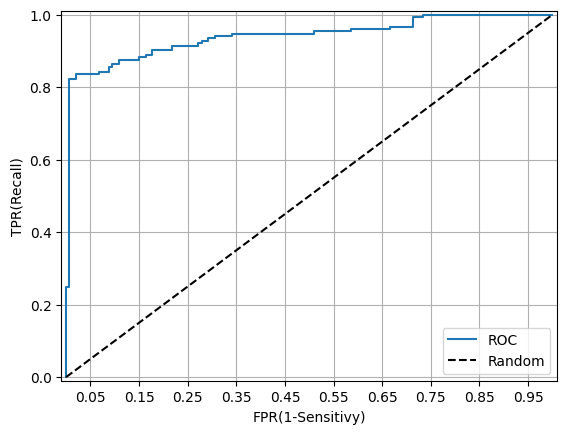

In [ ]:
plt.plot(fprs, tprs, label='ROC')
plt.plot([0,1], [0,1], '--k', label='Random')
start, end = plt.xlim()
plt.xticks(np.round(np.arange(start, end, 0.1), 2))

plt.xlim(-0.01, 1.01)
plt.ylim(-0.01, 1.01)
plt.xlabel('FPR(1-Sensitivy)')
plt.ylabel('TPR(Recall)')
plt.grid()
plt.legend()

plt.show()

In [ ]:
# 원래 ROC 는
# 파란선 밑의 영역이 AUC 가 됩니다.  (1에 가까울수록 좋음.)
# 점선에 가까울수록 성능이 안좋습니다.


In [ ]:
from sklearn.metrics import roc_auc_score

In [ ]:
roc_auc = roc_auc_score(y_test, predict)
print('ROC AUC Score:', roc_auc)

ROC AUC Score: 0.8842870481525944
